#### **Clustering Labs: Geometry, Density, Embeddings, Validation, and t-SNE Traps**

Five compact labs for seeing how clustering algorithms behave before applying them to complex data.

- **Lab 1:** K-Means vs GMM on anisotropic blobs
- **Lab 2:** DBSCAN vs HDBSCAN on mixed-density moons, circles, and blobs
- **Lab 3:** TMNIST embeddings with PCA, UMAP, and HDBSCAN
- **Lab 4:** Validation and cluster profiling with average glyph images
- **Lab 5:** The t-SNE trap on pure Gaussian noise

This notebook assumes the environment already has the required packages installed. It does not install anything.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

import umap

try:
    from sklearn.cluster import HDBSCAN as SklearnHDBSCAN
    HDBSCAN_BACKEND = "sklearn"
except ImportError:
    import hdbscan
    SklearnHDBSCAN = None
    HDBSCAN_BACKEND = "hdbscan"

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

sns.set_theme(
    context="notebook",
    style="whitegrid",
    palette="Set2",
    rc={
        "figure.dpi": 130,
        "savefig.dpi": 180,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelcolor": "#334155",
        "text.color": "#111827",
        "xtick.color": "#64748b",
        "ytick.color": "#64748b",
        "grid.color": "#e5e7eb",
        "grid.linewidth": 0.7,
    },
)

project_root = Path.cwd()
tmnist_path = project_root / "data" / "TMNIST.csv"
visualization_dir = project_root / "lab_visualizations"
visualization_dir.mkdir(exist_ok=True)

print(f"TMNIST path: {tmnist_path}")
print(f"HDBSCAN backend: {HDBSCAN_BACKEND}")

TMNIST path: /home/jaumemanero/_DEVELOPMENT/_Notebooks/Machine-Learning-II/12-Unsupervised/data/TMNIST.csv
HDBSCAN backend: sklearn


In [2]:
def fit_hdbscan(X, min_cluster_size=30, min_samples=None, metric="euclidean"):
    if HDBSCAN_BACKEND == "sklearn":
        model = SklearnHDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric=metric,
        )
        labels = model.fit_predict(X)
    else:
        model = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric=metric,
        )
        labels = model.fit_predict(X)
    return model, labels

def label_palette(labels):
    labels = np.asarray(labels)
    unique = np.array(sorted(pd.unique(labels)))
    colors = sns.color_palette("tab10", n_colors=max(10, len(unique)))
    color_map = {}
    for i, label in enumerate(unique):
        color_map[label] = "#cbd5e1" if label == -1 else colors[i % len(colors)]
    return [color_map[label] for label in labels]

def scatter_clusters(ax, X, labels, title, subtitle=None, centers=None):
    ax.scatter(
        X[:, 0], X[:, 1],
        c=label_palette(labels),
        s=18,
        alpha=0.82,
        linewidths=0,
    )
    if centers is not None:
        ax.scatter(
            centers[:, 0], centers[:, 1],
            c="#111827",
            marker="X",
            s=110,
            edgecolors="white",
            linewidths=1.2,
            zorder=5,
        )
    ax.set_title(title, loc="left", fontsize=13, pad=12)
    if subtitle:
        ax.text(0.0, 1.02, subtitle, transform=ax.transAxes, fontsize=9, color="#64748b")
    ax.set_xlabel("component 1")
    ax.set_ylabel("component 2")
    ax.set_aspect("equal", adjustable="datalim")

def save_current_figure(name):
    path = visualization_dir / name
    plt.savefig(path, bbox_inches="tight")
    print(f"Saved: {path}")

#### **Lab 1: K-Means vs GMM on Anisotropic Clusters**

K-Means partitions space with spherical Voronoi regions. Gaussian Mixture Models can learn covariance, so they adapt to elongated ellipses.

Saved: /home/jaumemanero/_DEVELOPMENT/_Notebooks/Machine-Learning-II/12-Unsupervised/lab_visualizations/lab1_kmeans_vs_gmm.png


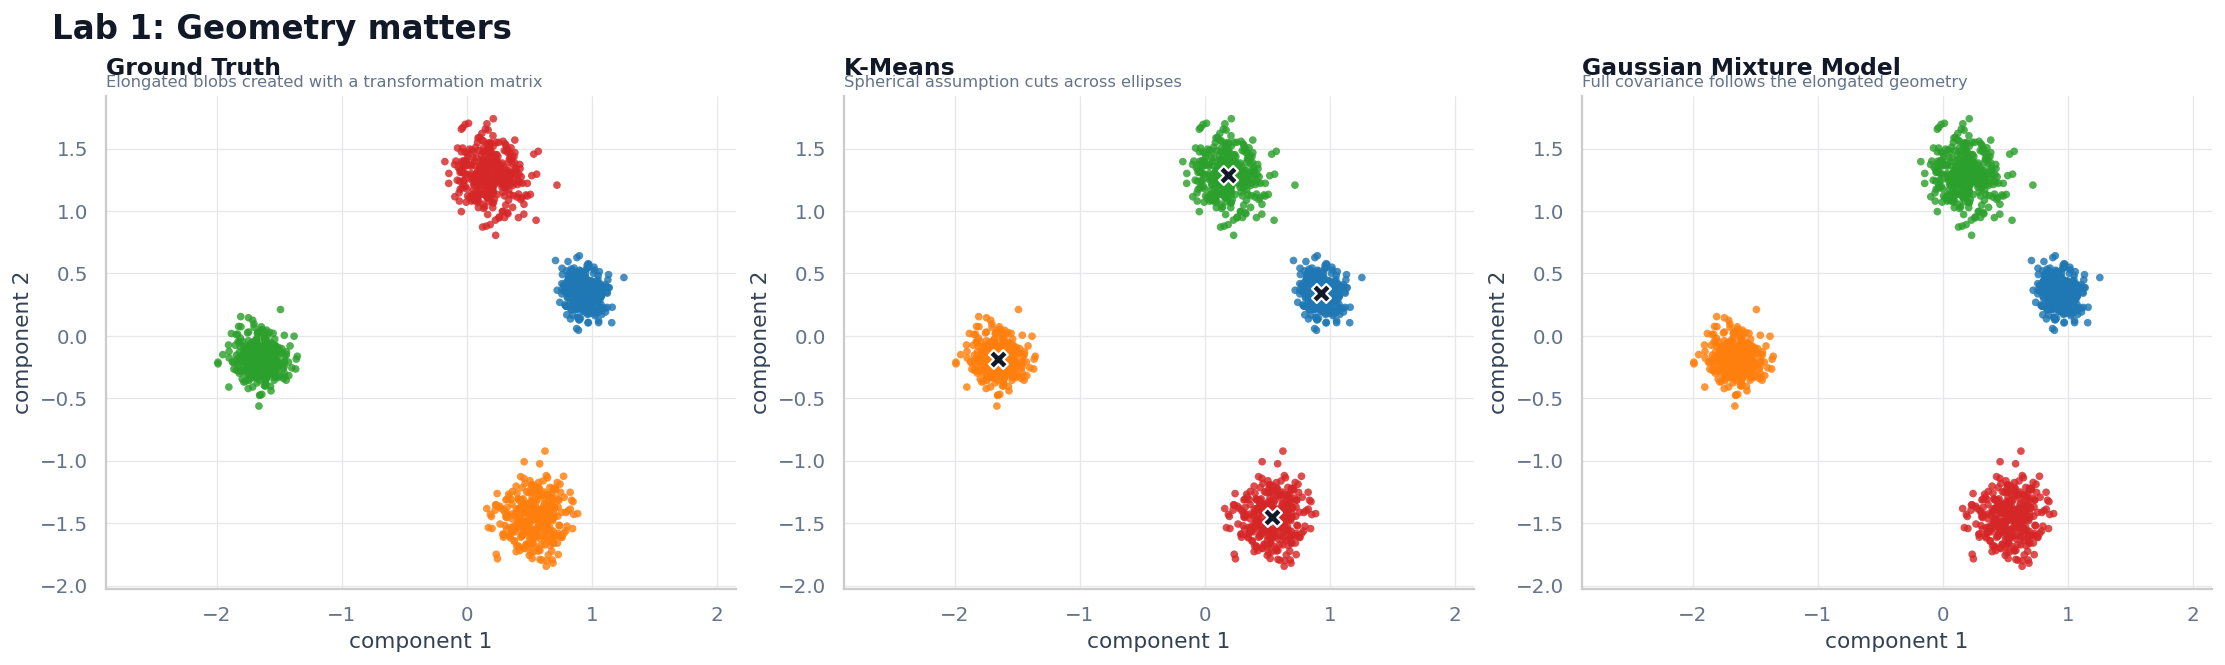

In [3]:
X_blob, y_blob = make_blobs(
    n_samples=1400,
    centers=4,
    cluster_std=[0.55, 0.85, 0.65, 0.9],
    random_state=RANDOM_SEED,
)

transformation = np.array([[0.78, -0.72], [1.35, 0.34]])
X_aniso = X_blob @ transformation
X_aniso = StandardScaler().fit_transform(X_aniso)

kmeans_lab1 = KMeans(n_clusters=4, n_init=20, random_state=RANDOM_SEED)
kmeans_labels_lab1 = kmeans_lab1.fit_predict(X_aniso)

gmm_lab1 = GaussianMixture(
    n_components=4,
    covariance_type="full",
    random_state=RANDOM_SEED,
)
gmm_labels_lab1 = gmm_lab1.fit_predict(X_aniso)

fig, axes = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)
scatter_clusters(axes[0], X_aniso, y_blob, "Ground Truth", "Elongated blobs created with a transformation matrix")
scatter_clusters(axes[1], X_aniso, kmeans_labels_lab1, "K-Means", "Spherical assumption cuts across ellipses", centers=kmeans_lab1.cluster_centers_)
scatter_clusters(axes[2], X_aniso, gmm_labels_lab1, "Gaussian Mixture Model", "Full covariance follows the elongated geometry")
fig.suptitle("Lab 1: Geometry matters", fontsize=18, fontweight="bold", x=0.02, ha="left")
save_current_figure("lab1_kmeans_vs_gmm.png")
plt.show()

#### **Lab 2: DBSCAN vs HDBSCAN on Variable Density**

DBSCAN uses one global density threshold. HDBSCAN builds a hierarchy and can handle clusters that live at different densities.

Saved: /home/jaumemanero/_DEVELOPMENT/_Notebooks/Machine-Learning-II/12-Unsupervised/lab_visualizations/lab2_dbscan_vs_hdbscan.png


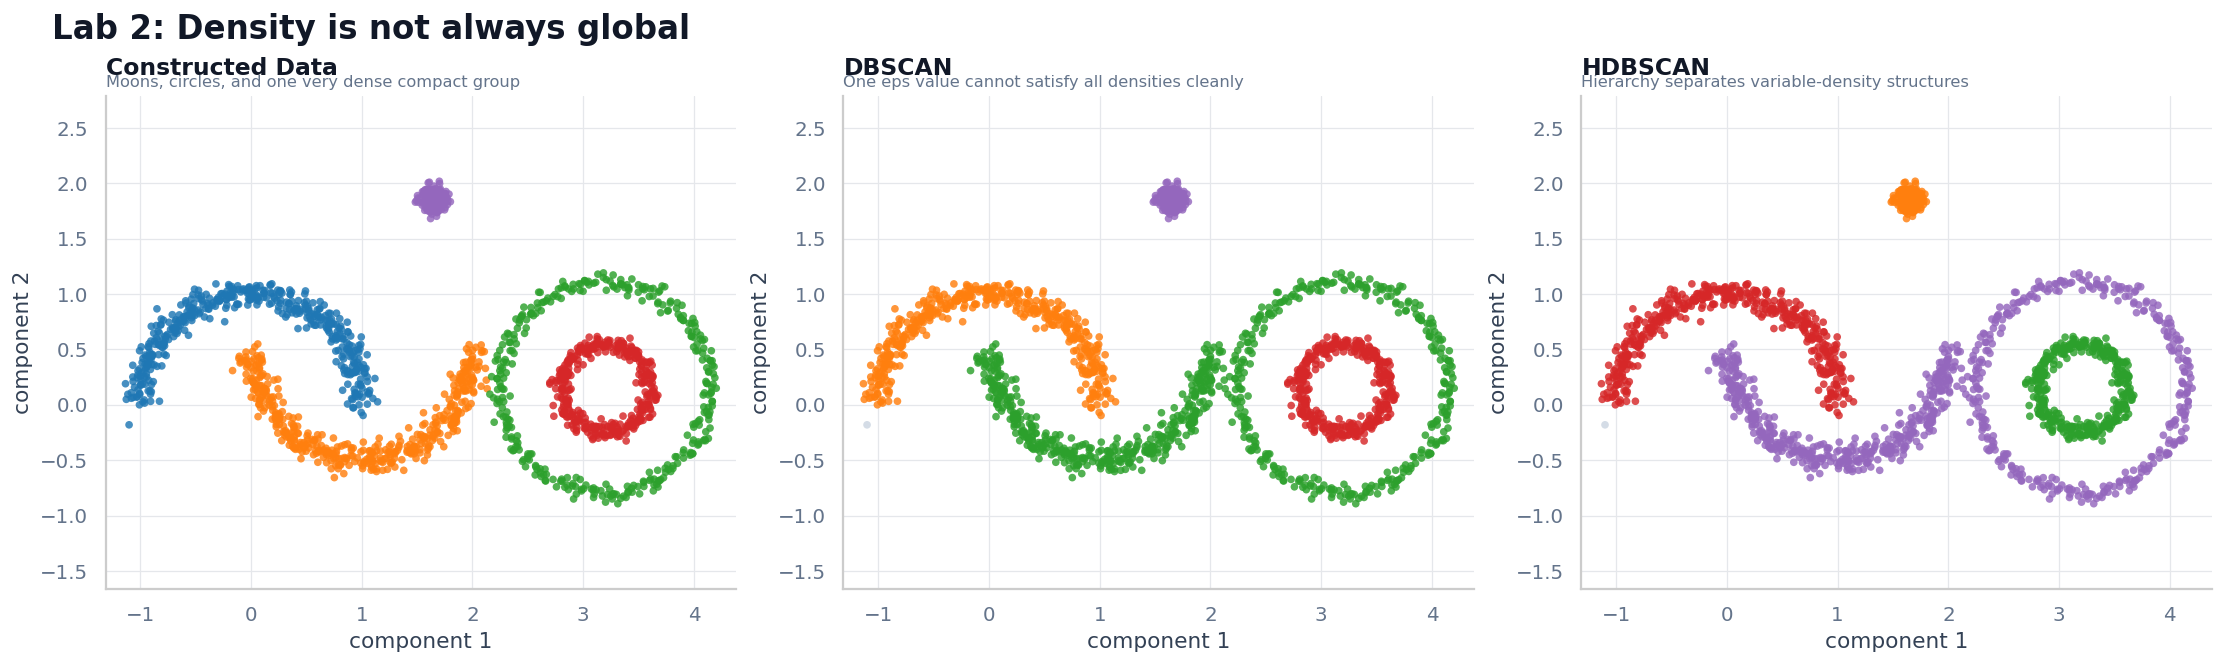

,algorithm,clusters_excluding_noise,noise_points
0,DBSCAN,4,1
1,HDBSCAN,4,1


In [4]:
moons_X, moons_y = make_moons(n_samples=900, noise=0.065, random_state=RANDOM_SEED)
circles_X, circles_y = make_circles(n_samples=700, noise=0.045, factor=0.42, random_state=RANDOM_SEED + 1)
circles_X = circles_X * 0.95 + np.array([3.2, 0.15])

dense_blob, _ = make_blobs(
    n_samples=260,
    centers=[[1.65, 1.85]],
    cluster_std=0.055,
    random_state=RANDOM_SEED + 2,
)

X_density = np.vstack([moons_X, circles_X, dense_blob])
true_density_labels = np.concatenate([
    moons_y,
    circles_y + 2,
    np.full(len(dense_blob), 4),
])

dbscan_lab2 = DBSCAN(eps=0.13, min_samples=8)
dbscan_labels_lab2 = dbscan_lab2.fit_predict(X_density)

hdbscan_lab2, hdbscan_labels_lab2 = fit_hdbscan(
    X_density,
    min_cluster_size=45,
    min_samples=8,
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)
scatter_clusters(axes[0], X_density, true_density_labels, "Constructed Data", "Moons, circles, and one very dense compact group")
scatter_clusters(axes[1], X_density, dbscan_labels_lab2, "DBSCAN", "One eps value cannot satisfy all densities cleanly")
scatter_clusters(axes[2], X_density, hdbscan_labels_lab2, "HDBSCAN", "Hierarchy separates variable-density structures")
fig.suptitle("Lab 2: Density is not always global", fontsize=18, fontweight="bold", x=0.02, ha="left")
save_current_figure("lab2_dbscan_vs_hdbscan.png")
plt.show()

pd.DataFrame({
    "algorithm": ["DBSCAN", "HDBSCAN"],
    "clusters_excluding_noise": [
        len(set(dbscan_labels_lab2)) - int(-1 in dbscan_labels_lab2),
        len(set(hdbscan_labels_lab2)) - int(-1 in hdbscan_labels_lab2),
    ],
    "noise_points": [
        int(np.sum(dbscan_labels_lab2 == -1)),
        int(np.sum(hdbscan_labels_lab2 == -1)),
    ],
})

#### **Lab 3: TMNIST Pipeline with PCA, UMAP, and HDBSCAN**

This lab loads `.data/tmnist.CSV`, selects one glyph, reduces pixels from 784 to 50 with PCA, compresses to a 2D UMAP embedding, then clusters the embedding with HDBSCAN.

/home/jaumemanero/ML/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved: /home/jaumemanero/_DEVELOPMENT/_Notebooks/Machine-Learning-II/12-Unsupervised/lab_visualizations/lab3_tmnist_embedding_pipeline.png


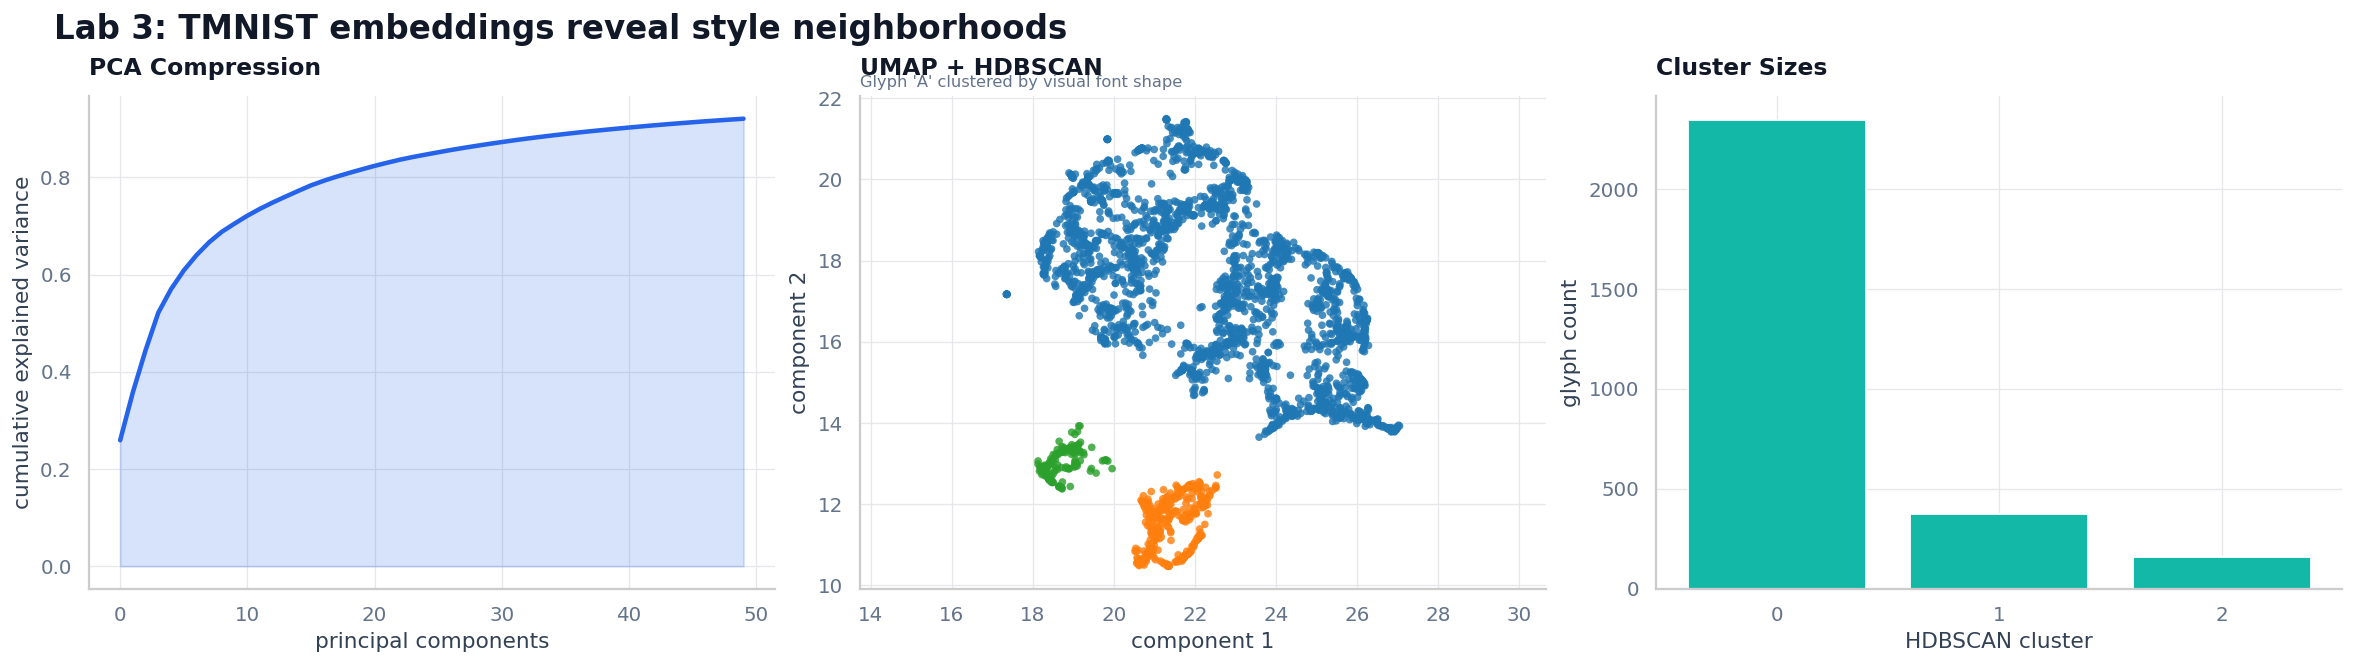

,labels,names,umap_1,umap_2,hdbscan_cluster
27,A,IBMPlexMono-ExtraLight,19.726604,16.045589,0
67,A,MontserratAlternates-ThinItalic,26.754957,13.867302,0
78,A,CrimsonPro[wght],21.390200,12.273046,1
100,A,PatuaOne-Regular,18.203409,12.913731,2
101,A,NunitoSans-SemiBold,20.233255,18.327806,0


In [5]:
def infer_tmnist_columns(df):
    lower_to_column = {column.lower(): column for column in df.columns}
    label_candidates = ["labels", "label", "character", "char", "target", "class"]
    font_candidates = ["names", "name", "font", "font_name", "fontname"]

    label_column = next((lower_to_column[name] for name in label_candidates if name in lower_to_column), None)
    font_column = next((lower_to_column[name] for name in font_candidates if name in lower_to_column), None)

    numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
    metadata_columns = {column for column in [label_column, font_column] if column is not None}
    pixel_columns = [column for column in numeric_columns if column not in metadata_columns]

    if len(pixel_columns) < 784:
        maybe_pixel_columns = [column for column in df.columns if str(column).isdigit()]
        if len(maybe_pixel_columns) >= 784:
            pixel_columns = maybe_pixel_columns[:784]

    if label_column is None:
        raise ValueError("Could not infer the TMNIST label column. Expected labels, label, character, char, target, or class.")
    if len(pixel_columns) < 784:
        raise ValueError(f"Expected at least 784 pixel columns, found {len(pixel_columns)}.")

    return label_column, font_column, pixel_columns[:784]

tmnist = pd.read_csv(tmnist_path)
label_column, font_column, pixel_columns = infer_tmnist_columns(tmnist)

TARGET_GLYPH = "A"
MAX_GLYPH_ROWS = 3500

glyph_data = tmnist.loc[tmnist[label_column].astype(str) == TARGET_GLYPH].copy()
if len(glyph_data) == 0:
    TARGET_GLYPH = "8"
    glyph_data = tmnist.loc[tmnist[label_column].astype(str) == TARGET_GLYPH].copy()

if len(glyph_data) > MAX_GLYPH_ROWS:
    glyph_data = glyph_data.sample(MAX_GLYPH_ROWS, random_state=RANDOM_SEED).sort_index()

X_pixels = glyph_data[pixel_columns].to_numpy(dtype=np.float32) / 255.0

pca_lab3 = PCA(n_components=50, random_state=RANDOM_SEED)
X_pca50 = pca_lab3.fit_transform(X_pixels)

umap_lab3 = umap.UMAP(
    n_components=2,
    n_neighbors=35,
    min_dist=0.04,
    metric="euclidean",
    random_state=RANDOM_SEED,
)
X_umap2 = umap_lab3.fit_transform(X_pca50)

hdbscan_lab3, hdbscan_labels_lab3 = fit_hdbscan(
    X_umap2,
    min_cluster_size=35,
    min_samples=10,
)

tmnist_embedding = glyph_data[[column for column in [label_column, font_column] if column is not None]].copy()
tmnist_embedding["umap_1"] = X_umap2[:, 0]
tmnist_embedding["umap_2"] = X_umap2[:, 1]
tmnist_embedding["hdbscan_cluster"] = hdbscan_labels_lab3

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
axes[0].plot(np.cumsum(pca_lab3.explained_variance_ratio_), color="#2563eb", linewidth=2.5)
axes[0].fill_between(np.arange(50), np.cumsum(pca_lab3.explained_variance_ratio_), alpha=0.18, color="#2563eb")
axes[0].set_title("PCA Compression", loc="left", fontsize=13, pad=12)
axes[0].set_xlabel("principal components")
axes[0].set_ylabel("cumulative explained variance")

scatter_clusters(axes[1], X_umap2, hdbscan_labels_lab3, "UMAP + HDBSCAN", f"Glyph '{TARGET_GLYPH}' clustered by visual font shape")

cluster_counts = pd.Series(hdbscan_labels_lab3).value_counts().sort_index()
bar_colors = ["#cbd5e1" if label == -1 else "#14b8a6" for label in cluster_counts.index]
axes[2].bar(cluster_counts.index.astype(str), cluster_counts.values, color=bar_colors)
axes[2].set_title("Cluster Sizes", loc="left", fontsize=13, pad=12)
axes[2].set_xlabel("HDBSCAN cluster")
axes[2].set_ylabel("glyph count")

fig.suptitle("Lab 3: TMNIST embeddings reveal style neighborhoods", fontsize=18, fontweight="bold", x=0.02, ha="left")
save_current_figure("lab3_tmnist_embedding_pipeline.png")
plt.show()

tmnist_embedding.head()

#### **Lab 4: Validation and Cluster Profiling**

Silhouette scores give a rough quantitative comparison. Average images give a qualitative profile: the cluster centroid becomes a ghost glyph for that font family style.

Saved: /home/jaumemanero/_DEVELOPMENT/_Notebooks/Machine-Learning-II/12-Unsupervised/lab_visualizations/lab4_validation_and_profiles.png


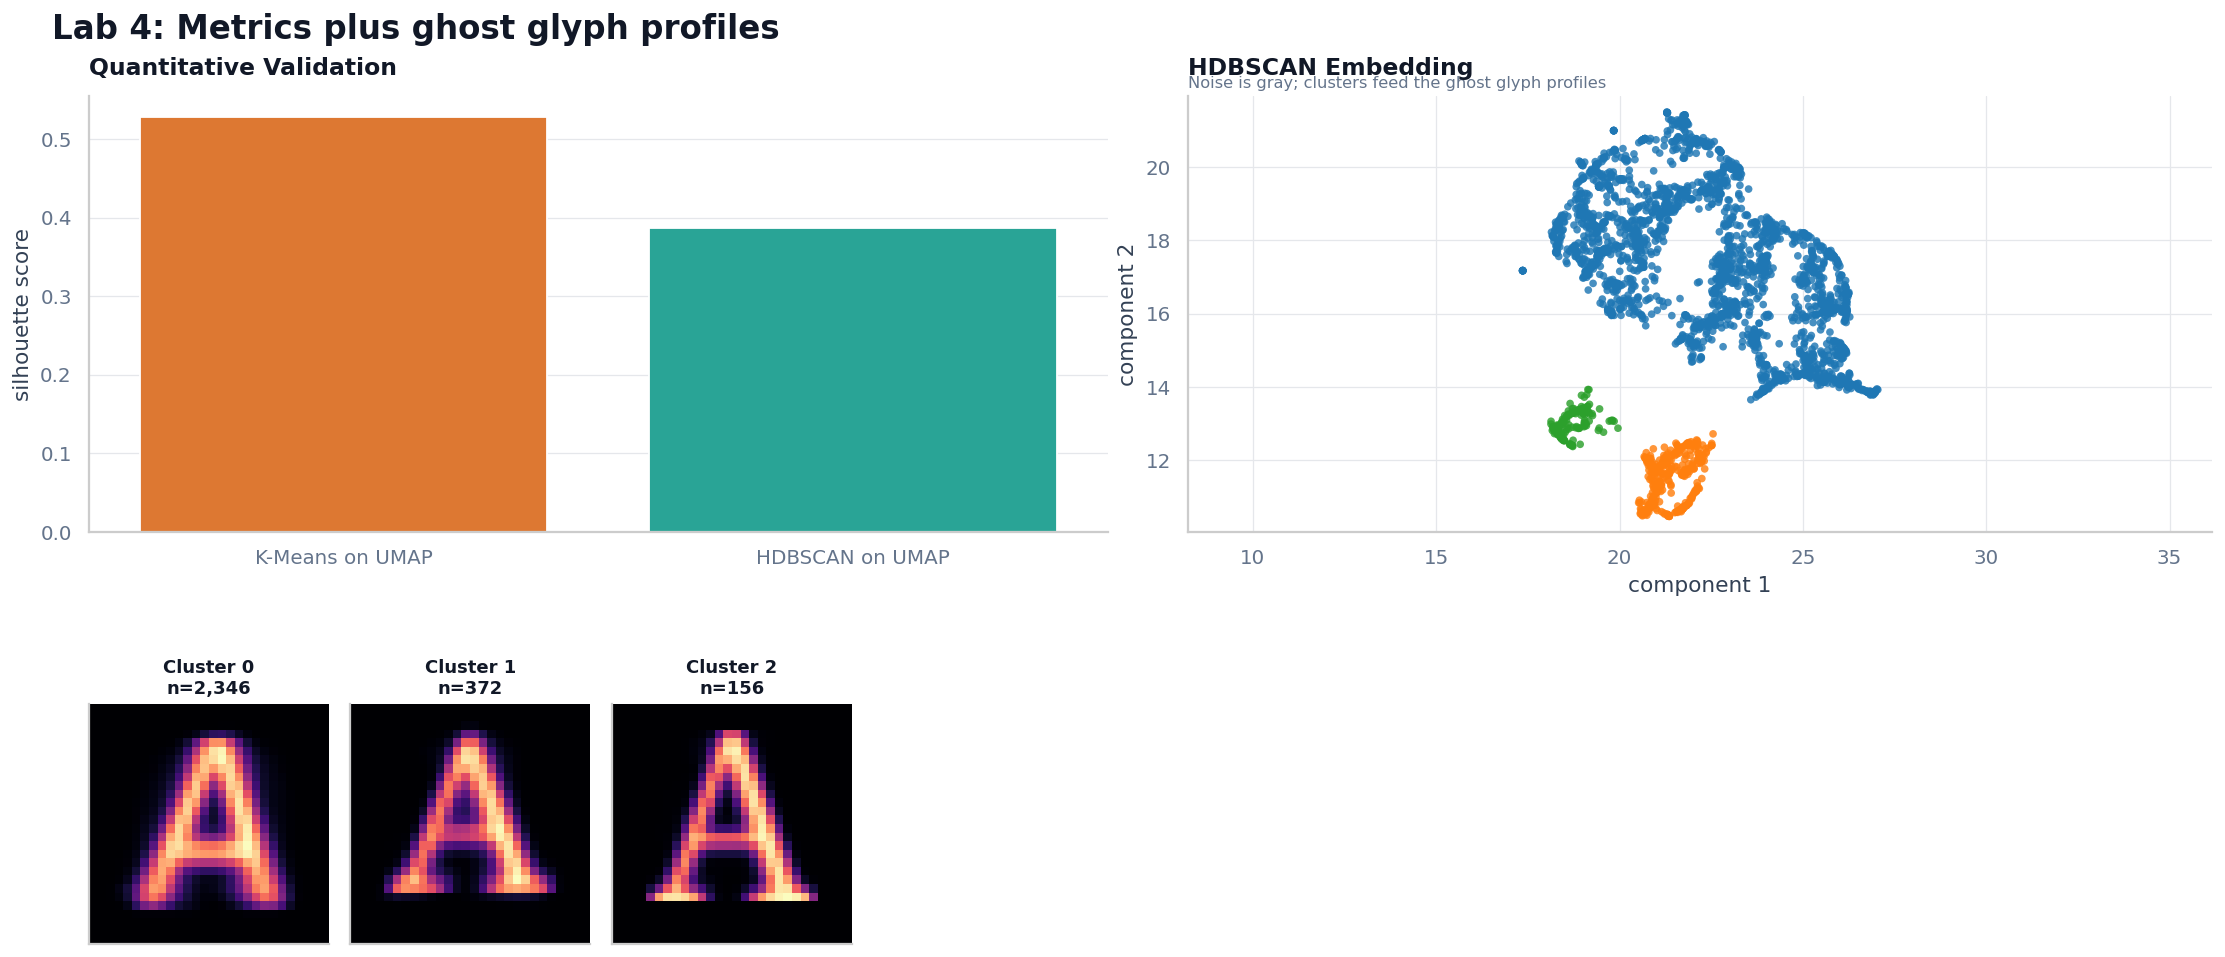

,algorithm,silhouette_score
0,K-Means on UMAP,0.527792
1,HDBSCAN on UMAP,0.387069


In [6]:
def safe_silhouette(X, labels):
    labels = np.asarray(labels)
    keep = labels != -1
    usable_labels = labels[keep]
    if keep.sum() < 3 or len(np.unique(usable_labels)) < 2:
        return np.nan
    return silhouette_score(X[keep], usable_labels)

kmeans_lab4 = KMeans(
    n_clusters=max(2, len(set(hdbscan_labels_lab3)) - int(-1 in hdbscan_labels_lab3)),
    n_init=20,
    random_state=RANDOM_SEED,
)
kmeans_labels_lab4 = kmeans_lab4.fit_predict(X_umap2)

validation_scores = pd.DataFrame({
    "algorithm": ["K-Means on UMAP", "HDBSCAN on UMAP"],
    "silhouette_score": [
        safe_silhouette(X_umap2, kmeans_labels_lab4),
        safe_silhouette(X_umap2, hdbscan_labels_lab3),
    ],
})

hdbscan_clusters = sorted(label for label in pd.unique(hdbscan_labels_lab3) if label != -1)
n_clusters_to_plot = min(len(hdbscan_clusters), 12)
plot_clusters = hdbscan_clusters[:n_clusters_to_plot]

grid_columns = max(8, n_clusters_to_plot)
fig = plt.figure(figsize=(17, 8), constrained_layout=True)
grid = fig.add_gridspec(2, grid_columns)

ax_score = fig.add_subplot(grid[0, :4])
sns.barplot(data=validation_scores, x="algorithm", y="silhouette_score", ax=ax_score, palette=["#f97316", "#14b8a6"])
ax_score.set_title("Quantitative Validation", loc="left", fontsize=13, pad=12)
ax_score.set_xlabel("")
ax_score.set_ylabel("silhouette score")
ax_score.tick_params(axis="x", rotation=0)

ax_scatter = fig.add_subplot(grid[0, 4:])
scatter_clusters(ax_scatter, X_umap2, hdbscan_labels_lab3, "HDBSCAN Embedding", "Noise is gray; clusters feed the ghost glyph profiles")

for i, cluster in enumerate(plot_clusters):
    ax = fig.add_subplot(grid[1, i])
    cluster_pixels = X_pixels[hdbscan_labels_lab3 == cluster]
    average_image = cluster_pixels.mean(axis=0).reshape(28, 28)
    ax.imshow(average_image, cmap="magma", interpolation="nearest")
    ax.set_title(f"Cluster {cluster}\nn={len(cluster_pixels):,}", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Lab 4: Metrics plus ghost glyph profiles", fontsize=18, fontweight="bold", x=0.02, ha="left")
save_current_figure("lab4_validation_and_profiles.png")
plt.show()

validation_scores

#### **Lab 5: The t-SNE Trap**

t-SNE can create visually convincing islands from random noise, especially with low perplexity. A stability test with a different seed should break the illusion.

Saved: /home/jaumemanero/_DEVELOPMENT/_Notebooks/Machine-Learning-II/12-Unsupervised/lab_visualizations/lab5_tsne_trap.png


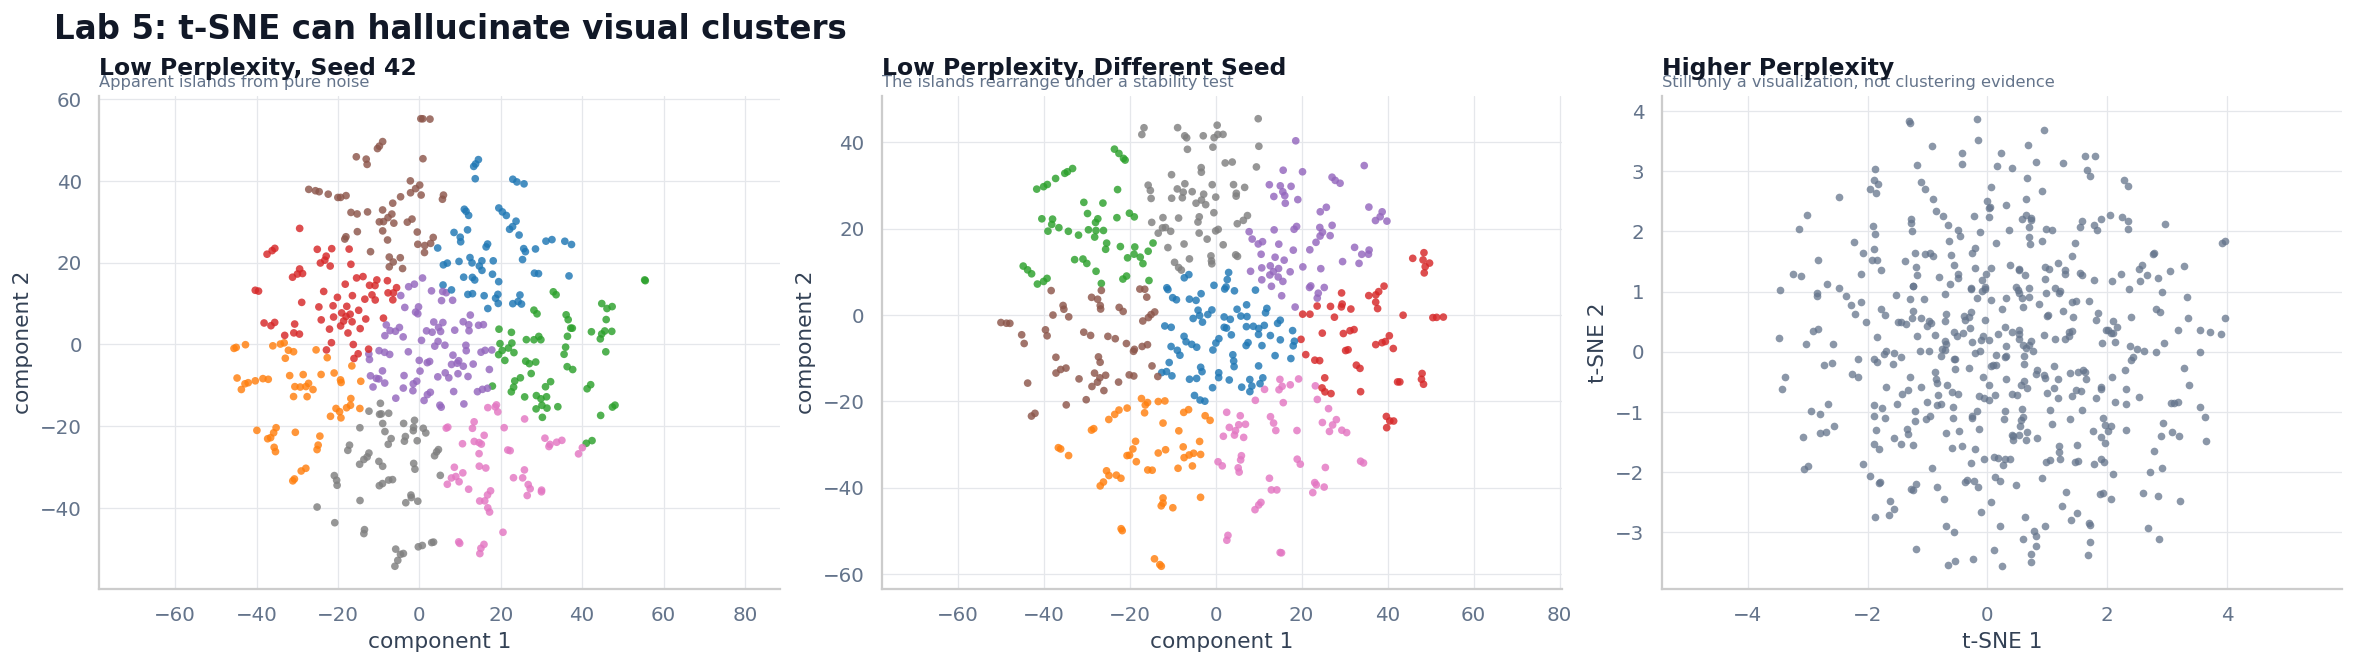

,run,perplexity,data_generating_process,interpretation
0,low perplexity seed 42,5,Gaussian noise,visual islands are artifacts unless stable and...
1,low perplexity seed 141,5,Gaussian noise,different seed should change the apparent isla...
2,higher perplexity seed 42,40,Gaussian noise,"less island-like, but still not proof of real ..."


In [7]:
X_noise = rng.normal(size=(500, 100))
X_noise_scaled = StandardScaler().fit_transform(X_noise)

tsne_low_seed_1 = TSNE(
    n_components=2,
    perplexity=5,
    learning_rate="auto",
    init="random",
    random_state=RANDOM_SEED,
)
tsne_low_seed_2 = TSNE(
    n_components=2,
    perplexity=5,
    learning_rate="auto",
    init="random",
    random_state=RANDOM_SEED + 99,
)
tsne_normal = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_SEED,
)

Z_low_1 = tsne_low_seed_1.fit_transform(X_noise_scaled)
Z_low_2 = tsne_low_seed_2.fit_transform(X_noise_scaled)
Z_normal = tsne_normal.fit_transform(X_noise_scaled)

fake_clusters_1 = KMeans(n_clusters=8, n_init=20, random_state=RANDOM_SEED).fit_predict(Z_low_1)
fake_clusters_2 = KMeans(n_clusters=8, n_init=20, random_state=RANDOM_SEED).fit_predict(Z_low_2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
scatter_clusters(axes[0], Z_low_1, fake_clusters_1, "Low Perplexity, Seed 42", "Apparent islands from pure noise")
scatter_clusters(axes[1], Z_low_2, fake_clusters_2, "Low Perplexity, Different Seed", "The islands rearrange under a stability test")
axes[2].scatter(Z_normal[:, 0], Z_normal[:, 1], s=18, alpha=0.75, color="#64748b", linewidths=0)
axes[2].set_title("Higher Perplexity", loc="left", fontsize=13, pad=12)
axes[2].text(0.0, 1.02, "Still only a visualization, not clustering evidence", transform=axes[2].transAxes, fontsize=9, color="#64748b")
axes[2].set_xlabel("t-SNE 1")
axes[2].set_ylabel("t-SNE 2")
axes[2].set_aspect("equal", adjustable="datalim")

fig.suptitle("Lab 5: t-SNE can hallucinate visual clusters", fontsize=18, fontweight="bold", x=0.02, ha="left")
save_current_figure("lab5_tsne_trap.png")
plt.show()

pd.DataFrame({
    "run": ["low perplexity seed 42", "low perplexity seed 141", "higher perplexity seed 42"],
    "perplexity": [5, 5, 40],
    "data_generating_process": ["Gaussian noise", "Gaussian noise", "Gaussian noise"],
    "interpretation": [
        "visual islands are artifacts unless stable and externally validated",
        "different seed should change the apparent island layout",
        "less island-like, but still not proof of real clusters",
    ],
})